<a href="https://colab.research.google.com/github/joaocanaslopes/AV_project-/blob/main/analises_spi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd

# Load the CSV file into a DataFrame named df
df = pd.read_csv('/content/total_com_spi12.csv')

# Display the first few rows of the DataFrame
df.head()

,ano,region,species,area_ha,production_t,productivity_kg_ha,irrigable_area_ha,precipitation_mm,mean_temp,mean_tmax,mean_tmin,annual_precipitation_anomaly,spi_12
0,2018,Alentejo,Cereais para grão,99278.0,369821.0,3725.105260,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544
1,2018,Alentejo,Trigo,18631.0,47839.0,2567.709731,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544
2,2018,Alentejo,Trigo mole,14677.0,37133.0,2530.012945,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544
3,2018,Alentejo,Trigo duro,3955.0,10706.0,2706.953224,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544
4,2018,Alentejo,Centeio,112.0,134.0,1196.428571,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544


In [20]:
import pandas as pd
import numpy as np

# Get unique regions
unique_regions = df['region'].unique()

# Dictionary to store most affected species per region
most_affected_species_by_region = {}

for region_name in unique_regions:
    print(f"\n--- Análise para a Região: {region_name} ---")

    # Filtrar dados para a região atual
    df_region = df[df['region'] == region_name].copy()

    # Filtrar dados para valores baixos de spi_12 (por exemplo, SPI-12 < -1.0 para seca moderada a extrema)
    df_drought = df_region[df_region['spi_12'] < -1.0].copy()

    # Calcular a produtividade média por hectare para cada espécie durante a seca na região
    avg_prod_drought = df_drought.groupby('species')['productivity_kg_ha'].mean().reset_index()
    avg_prod_drought = avg_prod_drought.rename(columns={'productivity_kg_ha': 'produtividade_media_seca_kg_ha'})

    # Calcular a produtividade média geral por hectare para cada espécie na região
    overall_avg_prod = df_region.groupby('species')['productivity_kg_ha'].mean().reset_index()
    # FIX: Correct column name for renaming
    overall_avg_prod = overall_avg_prod.rename(columns={'productivity_kg_ha': 'produtividade_media_geral_kg_ha'})

    # Juntar os dois dataframes
    comparison_df = pd.merge(overall_avg_prod, avg_prod_drought, on='species', how='left')

    # Preencher NaN na produtividade_media_seca_kg_ha com a produtividade_media_geral_kg_ha
    comparison_df['produtividade_media_seca_kg_ha'] = comparison_df['produtividade_media_seca_kg_ha'].fillna(comparison_df['produtividade_media_geral_kg_ha'])

    # Calcular a queda de produtividade devido à seca
    comparison_df['queda_produtividade_kg_ha'] = comparison_df['produtividade_media_geral_kg_ha'] - comparison_df['produtividade_media_seca_kg_ha']

    # Calcular a queda percentual
    comparison_df['queda_percentual'] = (comparison_df['queda_produtividade_kg_ha'] / comparison_df['produtividade_media_geral_kg_ha']) * 100
    comparison_df['queda_percentual'] = comparison_df['queda_percentual'].replace([np.inf, -np.inf], np.nan)
    comparison_df = comparison_df.fillna(0)

    # Filtrar apenas as espécies que tiveram queda na produtividade (queda_percentual > 0)
    most_affected_species = comparison_df[comparison_df['queda_percentual'] > 0]

    # Ordenar pela queda percentual em ordem decrescente para ver as mais afetadas primeiro
    most_affected_species = most_affected_species.sort_values(by='queda_percentual', ascending=False)

    if not most_affected_species.empty:
        print(f"Espécies mais afetadas negativamente por SPI-12 baixo (secas moderadas a extremas, SPI-12 < -1.0) em {region_name}:")
        display(most_affected_species.round(2))
        most_affected_species_by_region[region_name] = most_affected_species
    else:
        print(f"Não foram encontradas espécies afetadas negativamente por SPI-12 baixo em {region_name}, ou não há dados de seca para comparação.")



--- Análise para a Região: Alentejo ---
Espécies mais afetadas negativamente por SPI-12 baixo (secas moderadas a extremas, SPI-12 < -1.0) em Alentejo:


,species,produtividade_media_geral_kg_ha,produtividade_media_seca_kg_ha,queda_produtividade_kg_ha,queda_percentual
6,Amoras,1588.51,0.00,1588.51,100.00
11,Aveia forrageira,11141.70,0.00,11141.70,100.00
59,Milho forrageiro,30269.52,0.00,30269.52,100.00
78,Romã,2313.27,0.00,2313.27,100.00
70,Principais culturas forrageiras,12509.04,0.00,12509.04,100.00
62,Mirtilos,1067.00,0.00,1067.00,100.00
44,Frutos pequenos de baga,1507.82,0.00,1507.82,100.00
48,Groselha,392.86,0.00,392.86,100.00
43,Framboesas,1642.86,0.00,1642.86,100.00
20,Castanha,1732.98,200.75,1532.23,88.42



--- Análise para a Região: Algarve ---
Espécies mais afetadas negativamente por SPI-12 baixo (secas moderadas a extremas, SPI-12 < -1.0) em Algarve:


,species,produtividade_media_geral_kg_ha,produtividade_media_seca_kg_ha,queda_produtividade_kg_ha,queda_percentual
6,Amoras,783.33,0.00,783.33,100.00
9,Arroz,4382.93,0.00,4382.93,100.00
11,Aveia forrageira,9198.97,0.00,9198.97,100.00
62,Mirtilos,1291.67,0.00,1291.67,100.00
43,Framboesas,1498.80,0.00,1498.80,100.00
70,Principais culturas forrageiras,9629.88,0.00,9629.88,100.00
59,Milho forrageiro,20525.59,0.00,20525.59,100.00
44,Frutos pequenos de baga,1483.74,0.00,1483.74,100.00
18,Batata de sequeiro,7987.68,250.00,7737.68,96.87
88,Triticale,943.72,228.81,714.91,75.75


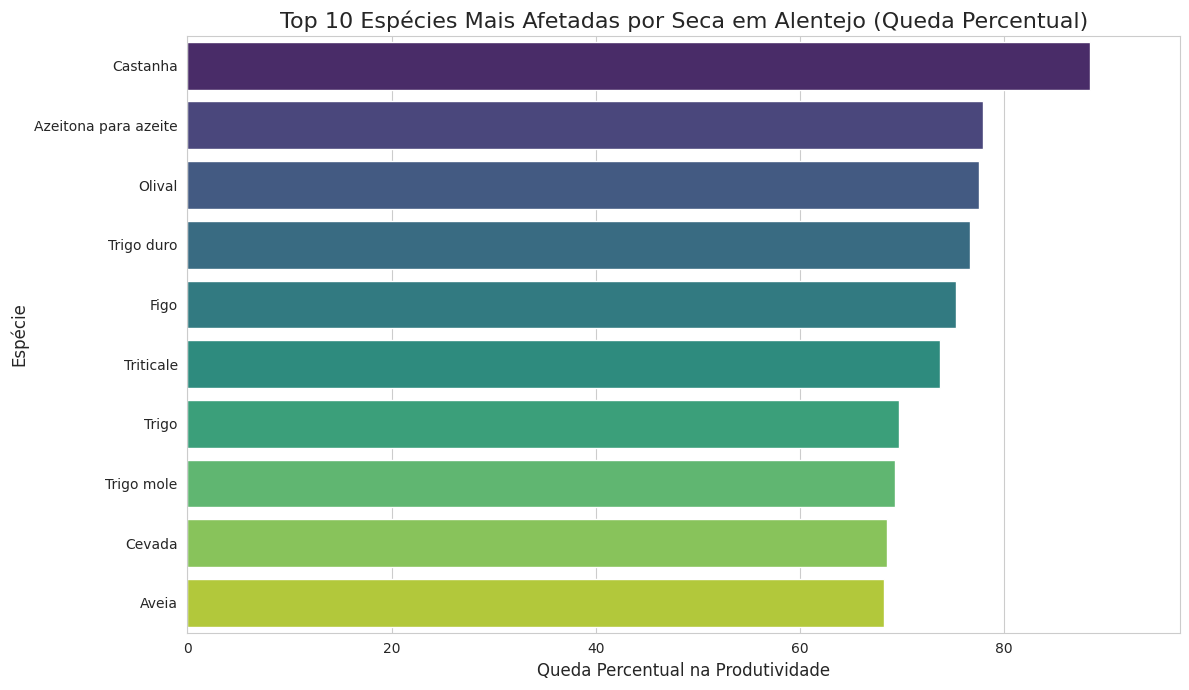

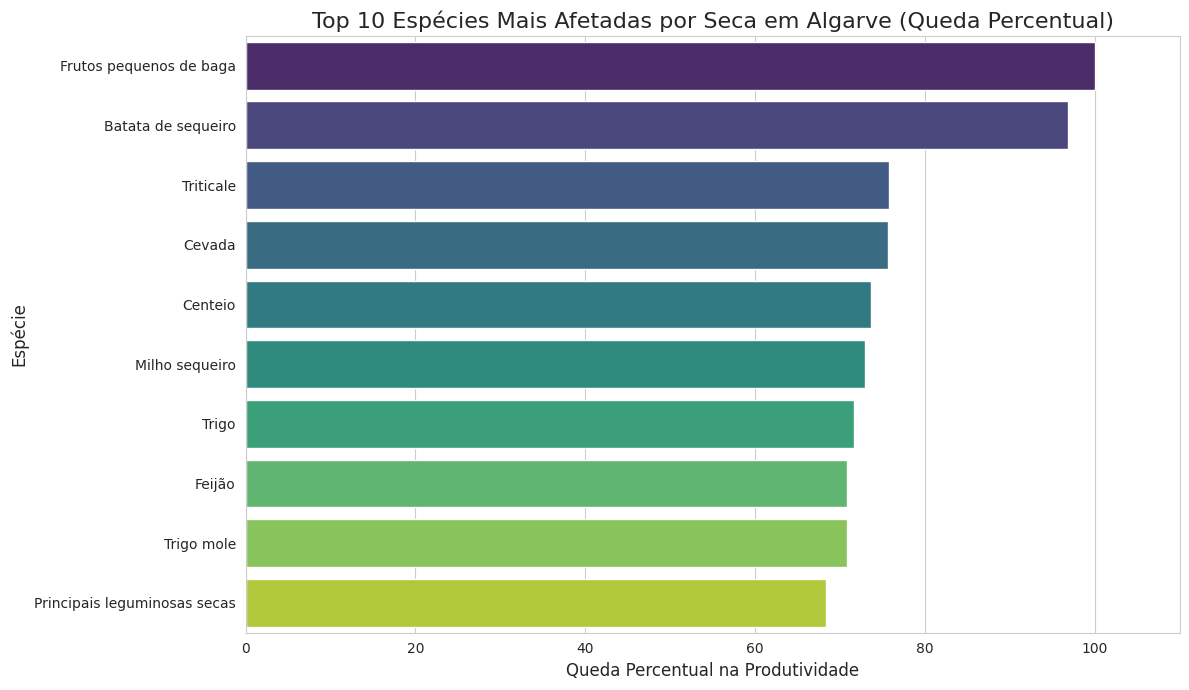

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

for region_name, affected_species_df in most_affected_species_by_region.items():
    if not affected_species_df.empty:
        # Determine how many species to skip based on the region
        skip_count = 0
        if region_name == 'Algarve':
            skip_count = 7
        elif region_name == 'Alentejo':
            skip_count = 9

        # Skip the specified number of top species and then select the next 10
        processed_df = affected_species_df.iloc[skip_count:]
        top_10_affected = processed_df.head(10)

        if not top_10_affected.empty: # Check if there are still species to plot after skipping
            plt.figure(figsize=(12, 7))
            # Updated sns.barplot call to address FutureWarning
            sns.barplot(x='queda_percentual', y='species', data=top_10_affected, palette='viridis', hue='species', legend=False)
            plt.title(f'Top 10 Espécies Mais Afetadas por Seca em {region_name} (Queda Percentual)', fontsize=16)
            plt.xlabel('Queda Percentual na Produtividade', fontsize=12)
            plt.ylabel('Espécie', fontsize=12)
            # Adjust x-axis limit for better visualization, only if top_10_affected is not empty
            max_val = top_10_affected['queda_percentual'].max()
            if max_val > 0:
                plt.xlim(0, max_val * 1.1) # Ensure there's a positive max to avoid issues with empty or zero data
            else:
                plt.xlim(0, 10) # Default small range if max_val is zero or negative (shouldn't happen with % drop > 0)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Nenhuma espécie restante para visualizar em {region_name} após excluir as primeiras {skip_count} e tentar obter as top 10.")
    else:
        print(f"Nenhuma espécie afetada para visualização em {region_name}.")


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm

# The DataFrame 'df' is already loaded in the environment from previous cells.

def plot_productivity_and_spi12(selected_region, selected_species):
    clear_output(wait=True)

    # Filter data for the selected region and species
    df_filtered = df[(df['region'] == selected_region) & (df['species'] == selected_species)].copy()

    if df_filtered.empty:
        print(f"Não há dados disponíveis para a cultura: {selected_species} na região de {selected_region}")
        return

    # Calculate mean productivity per year for the selected species in the selected region
    productivity_by_year = df_filtered.groupby('ano')['productivity_kg_ha'].mean().reset_index()

    # Calculate mean spi_12 per year for the selected species in the selected region
    spi12_for_species_by_year = df_filtered.groupby('ano')['spi_12'].mean().reset_index()
    spi12_for_species_by_year = spi12_for_species_by_year.rename(columns={'spi_12': 'spi_12_mean'})

    # Merge productivity and SPI-12 data
    merged_data = pd.merge(productivity_by_year, spi12_for_species_by_year, on='ano', how='left')

    # Sort by year to ensure correct plotting order
    merged_data = merged_data.sort_values(by='ano')

    # Set up the plot with two subplots: one for the line chart, one for the SPI-12 color bar
    fig, (ax1, ax2) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(12, 8),
        gridspec_kw={'height_ratios': [4, 1]}, # Main plot is 4 times taller than the color scale
        sharex=True # Share the x-axis to align years perfectly
    )

    # --- Plot 1: Productivity Line Chart ---
    sns.lineplot(
        x='ano',
        y='productivity_kg_ha',
        data=merged_data,
        marker='o',
        ax=ax1,
        color='darkgreen'
    )
    ax1.set_title(f'Produtividade Anual de {selected_species} em {selected_region} (kg/ha)', fontsize=16)
    ax1.set_ylabel('Produtividade (kg/ha)', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_xlabel('') # Remove x-label from top plot as it will be on the bottom plot

    # --- Plot 2: SPI-12 Color Scale (Continuous) ---
    cmap = plt.cm.RdBu # Red for dry (negative SPI), Blue for wet (positive SPI)
    # Use TwoSlopeNorm for custom min, max, and center (white at 0)
    norm = TwoSlopeNorm(vmin=-2.5, vcenter=0., vmax=1.5)

    years_to_plot = merged_data['ano'].unique()
    spi12_values_for_years = merged_data['spi_12_mean'].values

    # Create a 2D array for imshow to represent the color scale. Each column is a year.
    img_data = spi12_values_for_years.reshape(1, -1)

    # Plot the image on ax2
    im = ax2.imshow(
        img_data,
        cmap=cmap,
        norm=norm,
        aspect='auto',
        extent=[years_to_plot.min() - 0.5, years_to_plot.max() + 0.5, 0, 1]
    )

    ax2.set_yticks([]) # Hide y-ticks for the color scale
    ax2.set_xlabel('Ano', fontsize=12)
    ax2.set_title(f'SPI-12 Médio Anual para {selected_species} em {selected_region} (Contexto de Seca/Humidade)', fontsize=14)

    # Create a colorbar for interpretation of SPI-12 values
    cbar = fig.colorbar(im, ax=ax2, orientation='horizontal', pad=0.2)
    cbar.set_label('SPI-12 (Vermelho: Seco [-2.5], Branco: Normal [0], Azul: Húmido [1.5])', fontsize=10)

    # Set x-ticks only on the bottom plot (ax2) since sharex=True
    ax2.set_xticks(merged_data['ano'])
    ax2.set_xticklabels(merged_data['ano'].astype(int), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


# --- Interactive Plot for ALGARVE ---
print("### Gráfico Interativo para a Região: Algarve")

algarve_df = df[df['region'] == 'Algarve']
unique_species_algarve = sorted(algarve_df['species'].unique().tolist())

species_dropdown_algarve = widgets.Dropdown(
    options=unique_species_algarve,
    description='Selecionar Cultura (Algarve):',
    disabled=False,
)

out_algarve = widgets.interactive_output(
    plot_productivity_and_spi12,
    {'selected_region': widgets.fixed('Algarve'), 'selected_species': species_dropdown_algarve}
)

display(widgets.VBox([species_dropdown_algarve, out_algarve]))


# --- Interactive Plot for ALENTEJO ---
print("\n### Gráfico Interativo para a Região: Alentejo")

alentejo_df = df[df['region'] == 'Alentejo']
unique_species_alentejo = sorted(alentejo_df['species'].unique().tolist())

species_dropdown_alentejo = widgets.Dropdown(
    options=unique_species_alentejo,
    description='Selecionar Cultura (Alentejo):',
    disabled=False,
)

out_alentejo = widgets.interactive_output(
    plot_productivity_and_spi12,
    {'selected_region': widgets.fixed('Alentejo'), 'selected_species': species_dropdown_alentejo}
)

display(widgets.VBox([species_dropdown_alentejo, out_alentejo]))


### Gráfico Interativo para a Região: Algarve



### Gráfico Interativo para a Região: Alentejo


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' DataFrame is already loaded as in previous cells

print("### Análise de Correlação entre SPI-12 e Produtividade por Espécie e Região ###")

correlation_results = []

for region_name in df['region'].unique():
    df_region = df[df['region'] == region_name].copy()

    # Calculate correlation for each species within the region
    for species_name in df_region['species'].unique():
        df_species = df_region[df_region['species'] == species_name].copy()

        # Ensure there's enough data to calculate correlation (at least 2 data points)
        if len(df_species) > 1:
            correlation = df_species['spi_12'].corr(df_species['productivity_kg_ha'])
            if not pd.isna(correlation):
                correlation_results.append({
                    'region': region_name,
                    'species': species_name,
                    'correlation_spi12_productivity': correlation
                })

correlation_df = pd.DataFrame(correlation_results)

if not correlation_df.empty:
    for region_name in correlation_df['region'].unique():
        print(f"\n--- Correlações para a Região: {region_name} ---")
        region_corr_df = correlation_df[correlation_df['region'] == region_name].sort_values(
            by='correlation_spi12_productivity', ascending=False
        )

        # Display top 10 most positively correlated species (productivity increases with higher SPI-12)
        print("Top 10 Espécies com Correlação Mais Positiva (Maior SPI-12 -> Maior Produtividade):")
        display(region_corr_df.head(10).round(3))

        # Display top 10 most negatively correlated species (productivity decreases with higher SPI-12)
        # A forte correlação negativa aqui pode indicar culturas mais sensíveis à seca, onde um SPI-12 baixo (seca) leva a uma produtividade ainda mais baixa.
        print("Top 10 Espécies com Correlação Mais Negativa (Maior SPI-12 -> Menor Produtividade ou vice-versa):")
        display(region_corr_df.tail(10).round(3))

    # Optional: Visualize correlations with a heatmap for the top X species if there are many
    # For a comprehensive view across all species and regions, a heatmap could be too dense.
    # Let's focus on the tabulated top/bottom for clarity for now.

else:
    print("Nenhum resultado de correlação encontrado.")


### Análise de Correlação entre SPI-12 e Produtividade por Espécie e Região ###

--- Correlações para a Região: Alentejo ---
Top 10 Espécies com Correlação Mais Positiva (Maior SPI-12 -> Maior Produtividade):


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,region,species,correlation_spi12_productivity
45,Alentejo,Limão,0.664
52,Alentejo,Vinha,0.568
14,Alentejo,Grão-de-bico,0.559
53,Alentejo,Uva para vinho,0.554
12,Alentejo,Principais leguminosas secas,0.523
44,Alentejo,Tangerina,0.517
0,Alentejo,Cereais para grão,0.514
32,Alentejo,Damasco,0.495
49,Alentejo,Castanha,0.490
8,Alentejo,Milho,0.478


Top 10 Espécies com Correlação Mais Negativa (Maior SPI-12 -> Menor Produtividade ou vice-versa):


,region,species,correlation_spi12_productivity
37,Alentejo,Frutos pequenos de baga,-0.060
40,Alentejo,Groselha,-0.060
41,Alentejo,Mirtilos,-0.060
38,Alentejo,Amoras,-0.060
46,Alentejo,Tangera,-0.066
50,Alentejo,Noz,-0.212
21,Alentejo,Tabaco,-0.338
10,Alentejo,Milho sequeiro,-0.357
22,Alentejo,Beterraba,-0.420
18,Alentejo,Principais culturas para indústria,-0.622



--- Correlações para a Região: Algarve ---
Top 10 Espécies com Correlação Mais Positiva (Maior SPI-12 -> Maior Produtividade):


,region,species,correlation_spi12_productivity
64,Algarve,Cevada,0.790
60,Algarve,Trigo mole,0.779
59,Algarve,Trigo,0.769
65,Algarve,Triticale,0.759
84,Algarve,Ameixa,0.735
71,Algarve,Feijão,0.732
69,Algarve,Arroz,0.723
63,Algarve,Aveia,0.699
70,Algarve,Principais leguminosas secas,0.670
58,Algarve,Cereais para grão,0.622


Top 10 Espécies com Correlação Mais Negativa (Maior SPI-12 -> Menor Produtividade ou vice-versa):


,region,species,correlation_spi12_productivity
90,Algarve,Romã,-0.061
77,Algarve,Milho forrageiro,-0.098
67,Algarve,Milho regadio,-0.107
74,Algarve,Batata de regadio,-0.126
80,Algarve,Pêra,-0.146
66,Algarve,Milho,-0.154
61,Algarve,Trigo duro,-0.158
83,Algarve,Cereja,-0.159
89,Algarve,Nespera,-0.304
81,Algarve,Maçã,-0.370
